# 1. Librerias Necesarias.

In [15]:
import wfdb

import numpy as np

import matplotlib.pyplot as plt

# 2. Rutas de las bases de datos

In [16]:
AFDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\AIFB'

QTDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\QT'

# 3. Cargar paciente AFIB

In [17]:
record = wfdb.rdrecord(
    f'{AFDB_PATH}/04015'
)

signal = record.p_signal[:, 0]

print(signal.shape)

(9205760,)


# 4. Graficar ECG completo (fragmento)

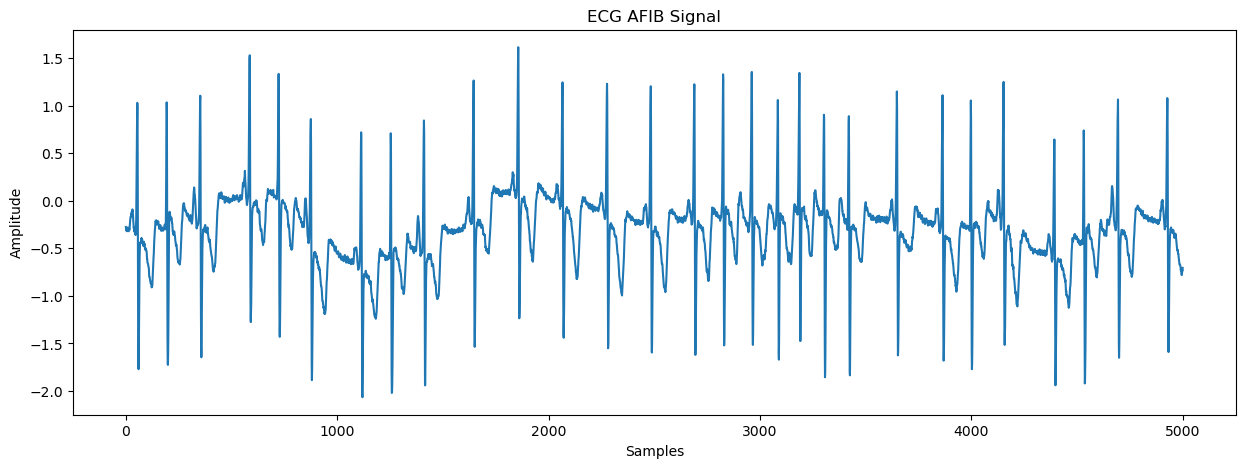

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(
    signal[:5000]
)

plt.title(
    'ECG AFIB Signal'
)

plt.xlabel(
    'Samples'
)

plt.ylabel(
    'Amplitude'
)

plt.show()

# 5. Segmentamos

In [19]:
FS = 250

WINDOW_SECONDS = 5

WINDOW_SIZE = FS * WINDOW_SECONDS

# 6. Primeras 10 ventanas ECG

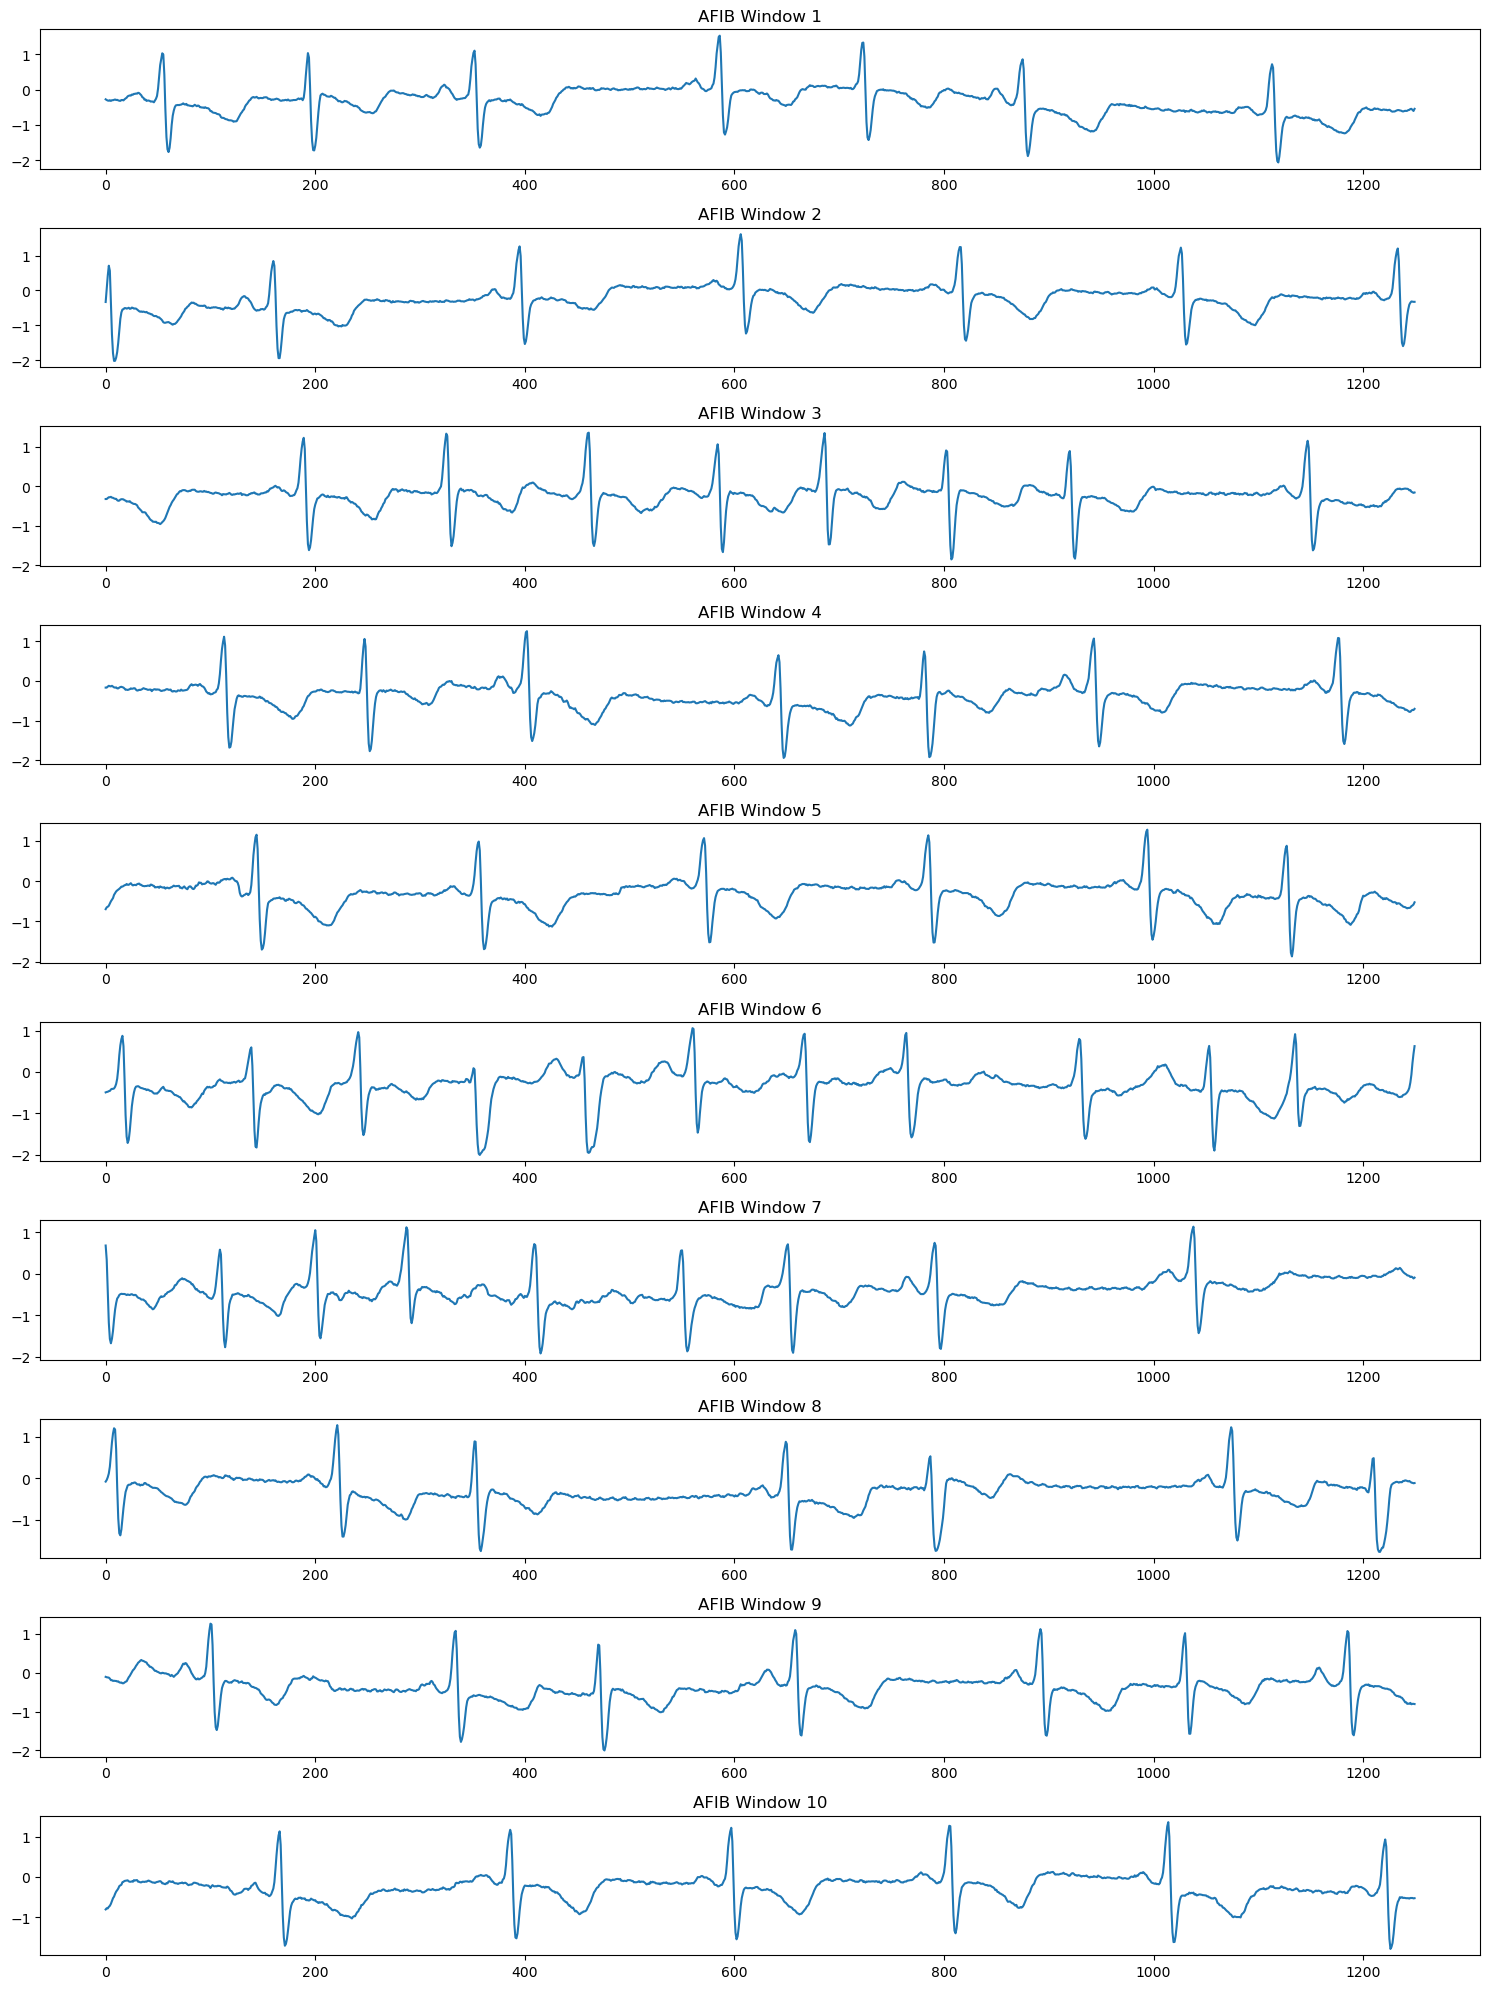

In [20]:
plt.figure(figsize=(15, 20))

for i in range(10):

    start = i * WINDOW_SIZE

    end = start + WINDOW_SIZE

    window = signal[start:end]

    plt.subplot(
        10,
        1,
        i + 1
    )

    plt.plot(window)

    plt.title(
        f'AFIB Window {i + 1}'
    )

plt.tight_layout()

plt.show()

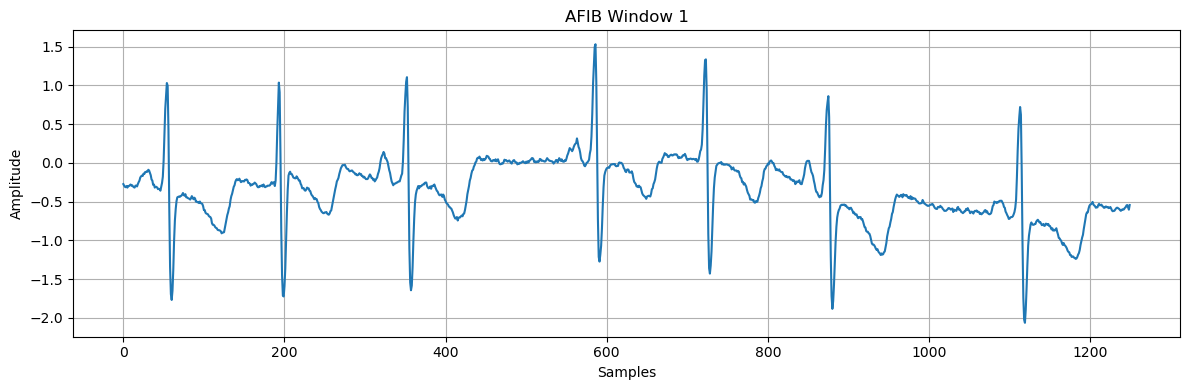

In [21]:
import matplotlib.pyplot as plt

# Define qué ventana quieres mostrar (0 para la primera, 1 para la segunda, etc.)
window_index = 0

# Ajustamos el tamaño de la figura para una sola gráfica
plt.figure(figsize=(12, 4))

# Calculamos el inicio y fin basados en el índice de la ventana seleccionada
start = window_index * WINDOW_SIZE
end = start + WINDOW_SIZE
window = signal[start:end]

# Graficamos la ventana directamente sin necesidad de subplots
plt.plot(window)
plt.title(f'AFIB Window {window_index + 1}')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)  # Agregamos una cuadrícula para que sea más fácil analizar la señal

plt.tight_layout()
plt.show()

# 7. Pacientes SANOS (QT)

In [22]:
import os

qt_records = []

for file in os.listdir(QTDB_PATH):

    if file.endswith('.dat'):

        qt_records.append(
            file.replace(
                '.dat',
                ''
            )
        )

print(qt_records[:10])

['sel100', 'sel102', 'sel103', 'sel104', 'sel114', 'sel116', 'sel117', 'sel123', 'sel14046', 'sel14157']


In [23]:
healthy_record = qt_records[0]

# 8. ECG sano

In [24]:
record_qt = wfdb.rdrecord(
    f'{QTDB_PATH}/{healthy_record}'
)

signal_qt = record_qt.p_signal[:, 0]

# 9. Graficamos el ECG de los pacientes sanos

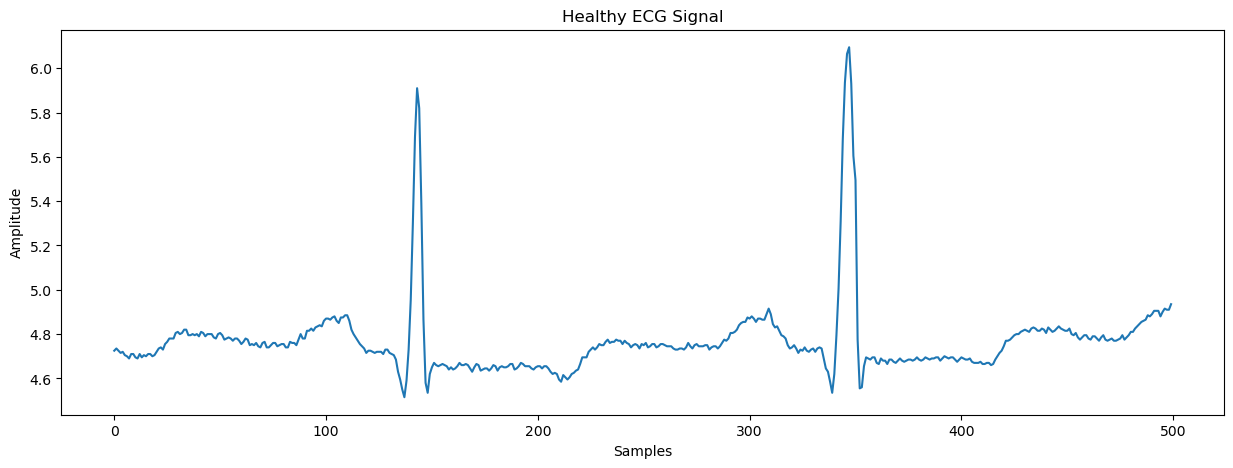

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(
    signal_qt[:500]
)

plt.title(
    'Healthy ECG Signal'
)

plt.xlabel(
    'Samples'
)

plt.ylabel(
    'Amplitude'
)

plt.show()

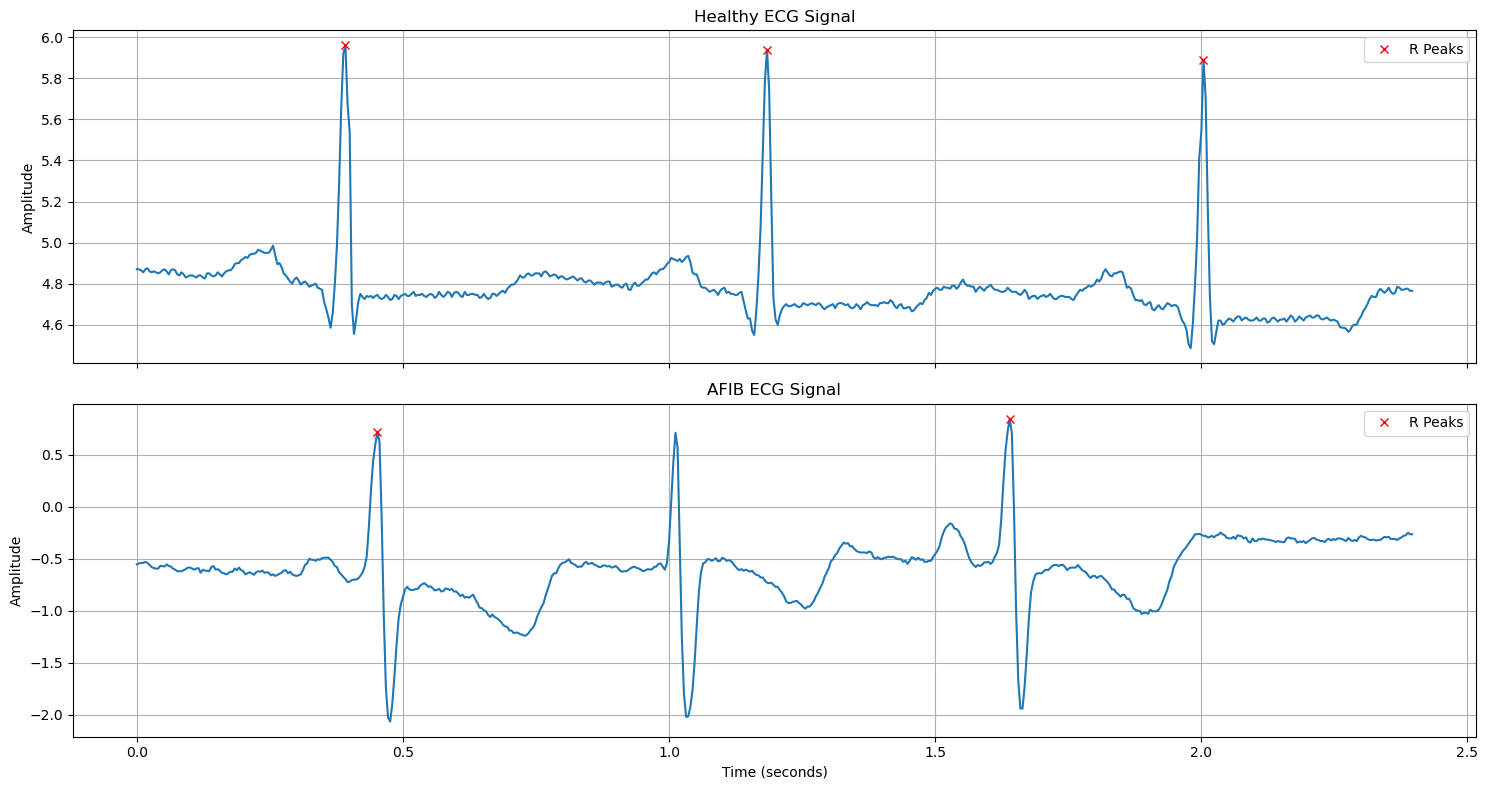

In [35]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

# ==================================================
# PATHS
# ==================================================

AFDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\AIFB'

QTDB_PATH = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\QT'

# ==================================================
# LOAD AFIB SIGNAL
# ==================================================

record_afib = wfdb.rdrecord(
    f'{AFDB_PATH}/04015'
)

signal_afib = record_afib.p_signal[:, 0]

# ==================================================
# LOAD HEALTHY SIGNAL
# ==================================================

qt_records = []

for file in os.listdir(QTDB_PATH):

    if file.endswith('.dat'):

        qt_records.append(
            file.replace('.dat', '')
        )

healthy_record = qt_records[0]

record_qt = wfdb.rdrecord(
    f'{QTDB_PATH}/{healthy_record}'
)

signal_qt = record_qt.p_signal[:, 0]

# ==================================================
# PARAMETERS
# ==================================================

FS = 250

ZOOM_SAMPLES = 600

START = 1000

END = START + ZOOM_SAMPLES

time_axis = np.arange(
    ZOOM_SAMPLES
) / FS

# ==================================================
# R-PEAK DETECTION
# ==================================================

peaks_qt, _ = find_peaks(
    signal_qt[START:END],
    distance=150,
    prominence=0.5
)

peaks_afib, _ = find_peaks(
    signal_afib[START:END],
    distance=150,
    prominence=0.5
)

# ==================================================
# PLOT
# ==================================================

fig, axs = plt.subplots(
    2,
    1,
    figsize=(15, 8),
    sharex=True
)

# ---------------------------
# HEALTHY ECG
# ---------------------------

axs[0].plot(
    time_axis,
    signal_qt[START:END],
    linewidth=1.5
)

axs[0].plot(
    peaks_qt / FS,
    signal_qt[START:END][peaks_qt],
    'rx',
    label='R Peaks'
)

axs[0].set_title(
    'Healthy ECG Signal'
)

axs[0].set_ylabel(
    'Amplitude'
)

axs[0].legend()

axs[0].grid(True)

# ---------------------------
# AFIB ECG
# ---------------------------

axs[1].plot(
    time_axis,
    signal_afib[START:END],
    linewidth=1.5
)

axs[1].plot(
    peaks_afib / FS,
    signal_afib[START:END][peaks_afib],
    'rx',
    label='R Peaks'
)

axs[1].set_title(
    'AFIB ECG Signal'
)

axs[1].set_xlabel(
    'Time (seconds)'
)

axs[1].set_ylabel(
    'Amplitude'
)

axs[1].legend()

axs[1].grid(True)

plt.tight_layout()

plt.show()

# Teoría:

*En la señal sana (Healthy ECG)*: Justo antes de cada complejo QRS (los picos altos con la x roja), se observa con total claridad una deflexión suave y redondeada hacia arriba. Esa es la onda P. Indica que las aurículas se están contrayendo de forma sincronizada y ordenada.

*En la señal con AFIB*: Si miras antes del primer y tercer pico, la onda P ha desaparecido por completo. En su lugar, la línea base muestra pequeñas oscilaciones irregulares (ruido o "ondas f" de fibrilación). Esto demuestra visualmente que las aurículas no se están contrayendo, sino que están "temblando" de forma caótica.